<img src="http://imgur.com/1ZcRyrc.png" style="float: left; margin: 20px; height: 55px">

# Time Series EDA Lab

---

This lab covers the exploratory toolkit you need **before** fitting any time series model. It walks through: 

- Loading and indexing a real-world time series
- Visualizing trend by resampling / rolling smoothing
- Testing for stationarity with the Augmented Dickey-Fuller (ADF) test
- Diagnosing the series using ACF and PACF plots

## About the Data

`residents.csv` contains a **quarterly resident population count**, in thousands, from **April 1971 to April 1993** (89 quarters):

| Column | Description |
|---|---|
| `date` | Quarter (month-year, e.g. `04-1971`) |
| `residents` | Resident population that quarter, in thousands |

We're going to hold the **final 8 quarters (1991–1993)** out completely. Everything in this EDA lab uses only the first **81 quarters (1971–1990)**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.style.use('fivethirtyeight')

%config InlineBackend.figure_format = 'retina'
%matplotlib inline

## Part 1 - Load and Set Aside the Holdout 

### 1. Load `residents.csv`, parse `date` as a datetime (format is `MM-YYYY`), and set it as the index.

In [3]:
# YOUR CODE HERE
df = pd.read_csv('./data/residents.csv', parse_dates=['date'], date_format='%m-%Y', index_col='date')
df.head(10)

,residents
date,
1971-04-01,13067.3
1971-07-01,13130.5
1971-10-01,13198.4
1972-01-01,13254.2
1972-04-01,13303.7
1972-07-01,13353.9
1972-10-01,13409.3
1973-01-01,13459.2
1973-04-01,13504.5


### 2. Set aside the final 8 quarters (1991–1993) as `holdout_df`. Keep the remaining 81 quarters (1971–1990) as `df_eda`.

In [8]:
# YOUR CODE HERE
df_eda = df.iloc[:-8]
holdout_df = df.iloc[-8:]


### 3. Plot the raw `residents` series. What do you notice about the overall trend? Does the quarter-to-quarter spread look roughly constant, or does it change over time?

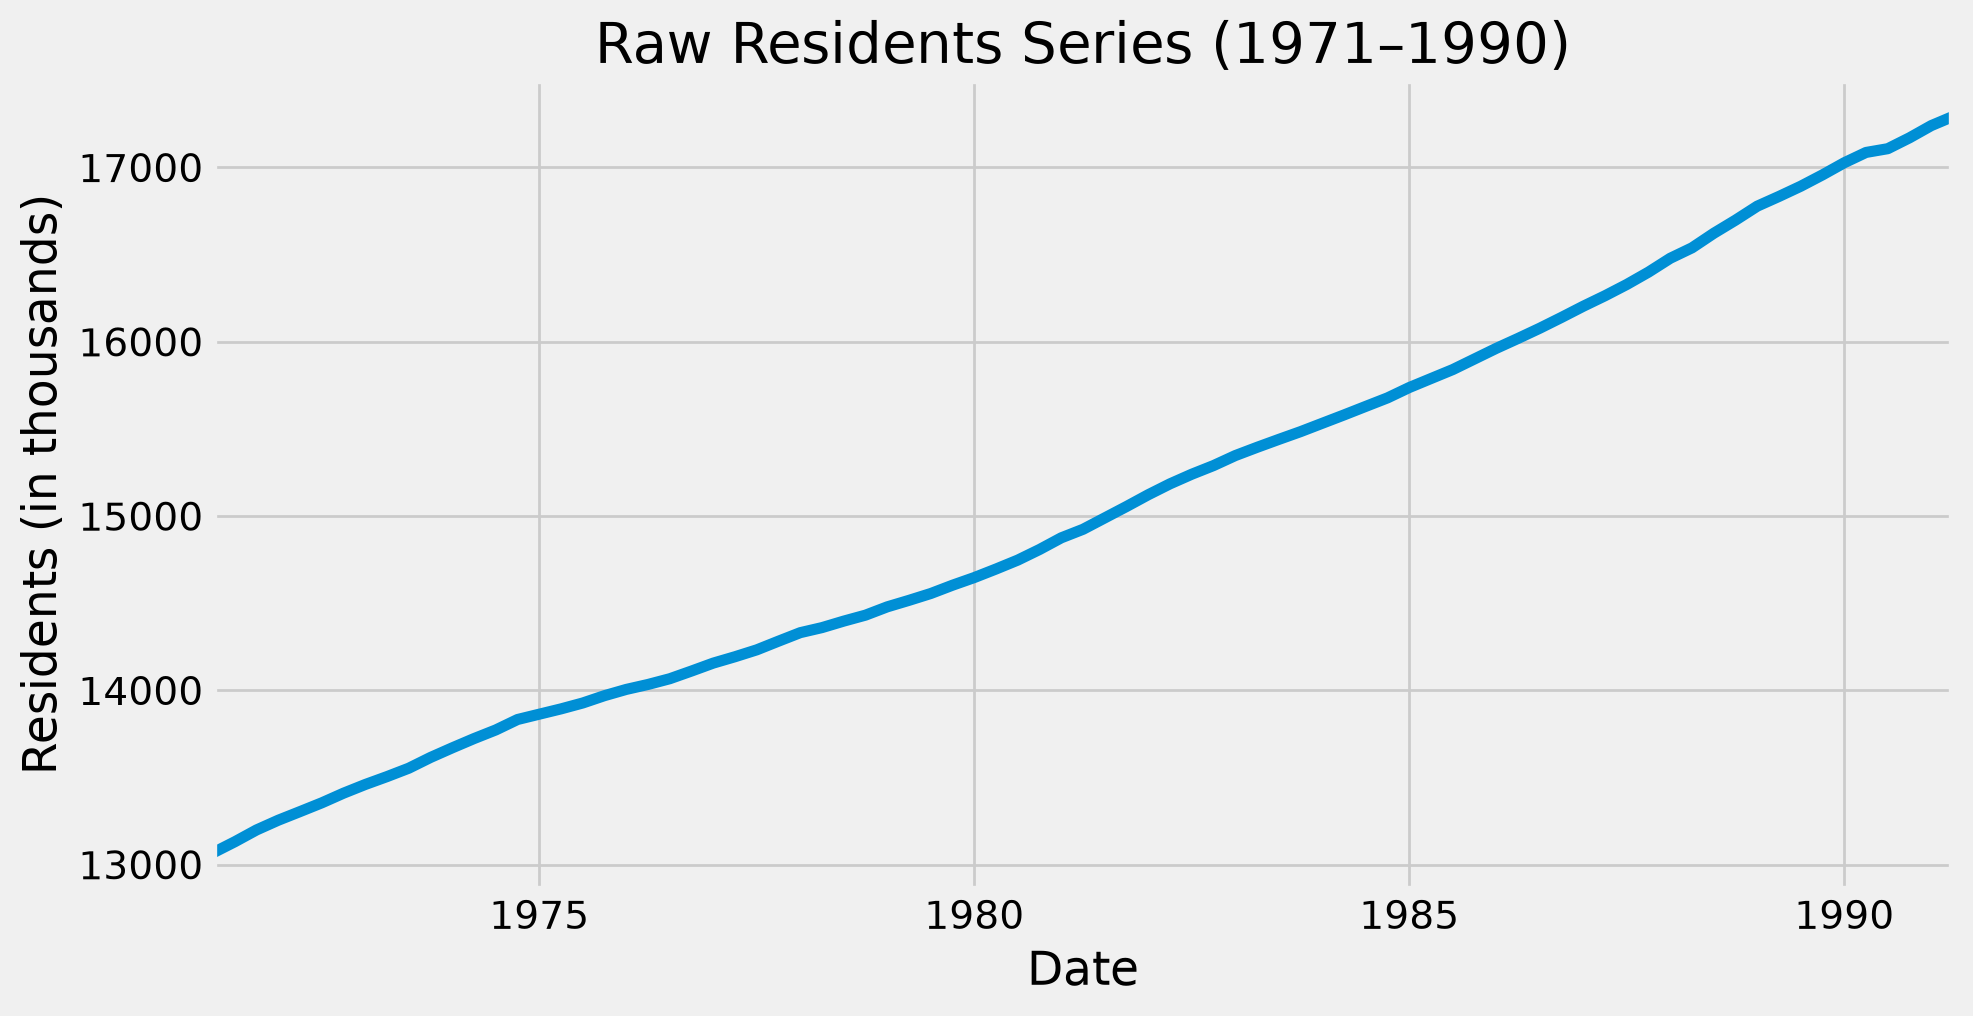

In [9]:
# YOUR CODE HERE
plt.figure(figsize=(10, 5))
df_eda['residents'].plot()
plt.title('Raw Residents Series (1971–1990)')
plt.xlabel('Date')
plt.ylabel('Residents (in thousands)')
plt.show()

**Observations:**
* **Overall Trend:** The series exhibits a clear, steady **upward trend** in resident population from 1971 through 1990.
* **Quarter-to-Quarter Spread:** The fluctuations and spread between quarters remain relatively consistent over time as the population grows.

## Part 2 - Seasonal Decomposition

A time series can be split into three components: **trend**, **seasonal**, and **residual**.

### 4. Decompose `residents` using `seasonal_decompose` (`period=4` since this is quarterly data). Plot the trend, seasonal, and residual components.

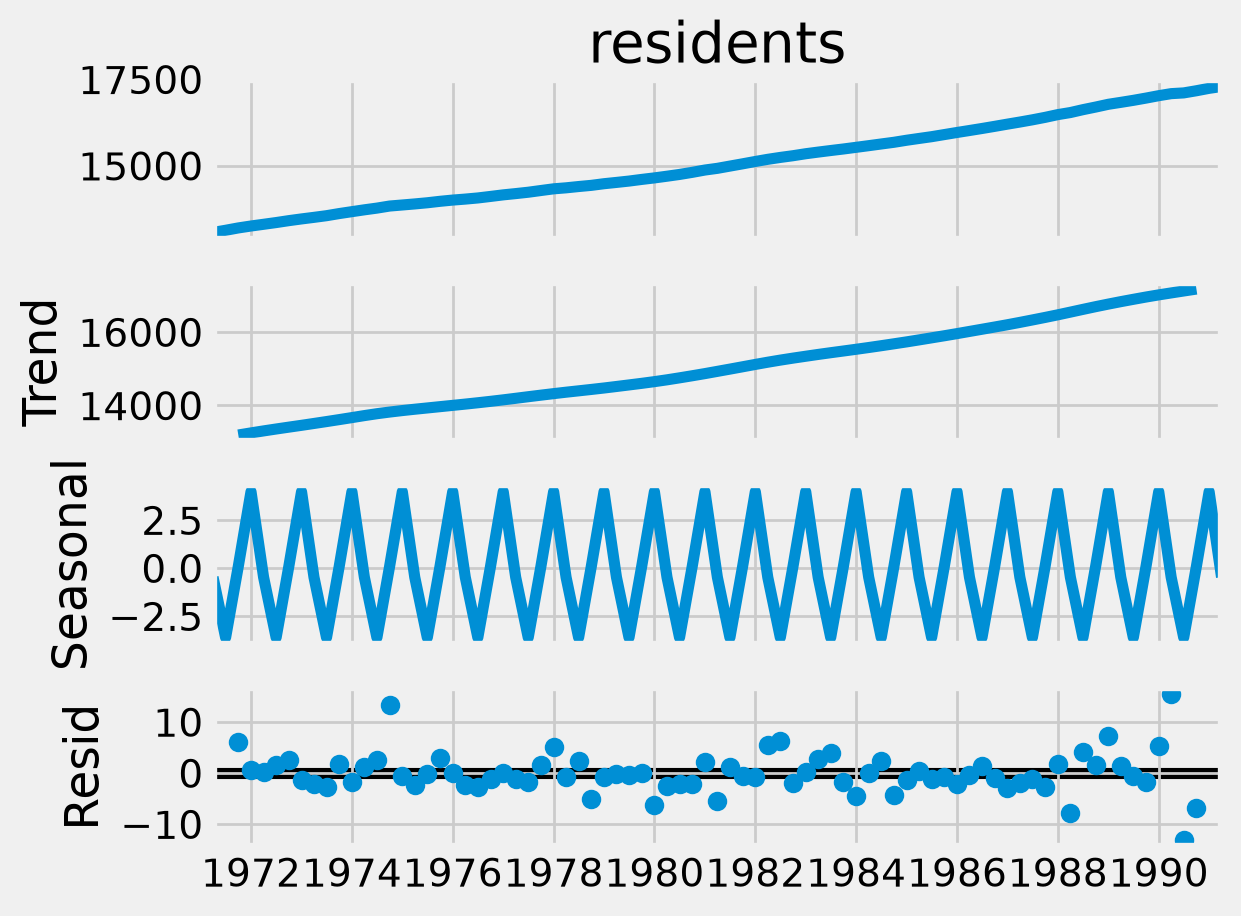

In [11]:
# YOUR CODE HERE
decomposition = seasonal_decompose(df_eda['residents'], period=4)
decomposition.plot()
plt.show()

## Part 3 - Visualizing Trend with Rolling Mean and Resampling.

With quarterly data, a 4-quarter (1-year) rolling window is the suitable choice, as it averages away any seasonal fluctuations and leaves just the trend.

### 5. Compute and plot a 4-quarter rolling mean of `residents`, overlaid on the raw series.

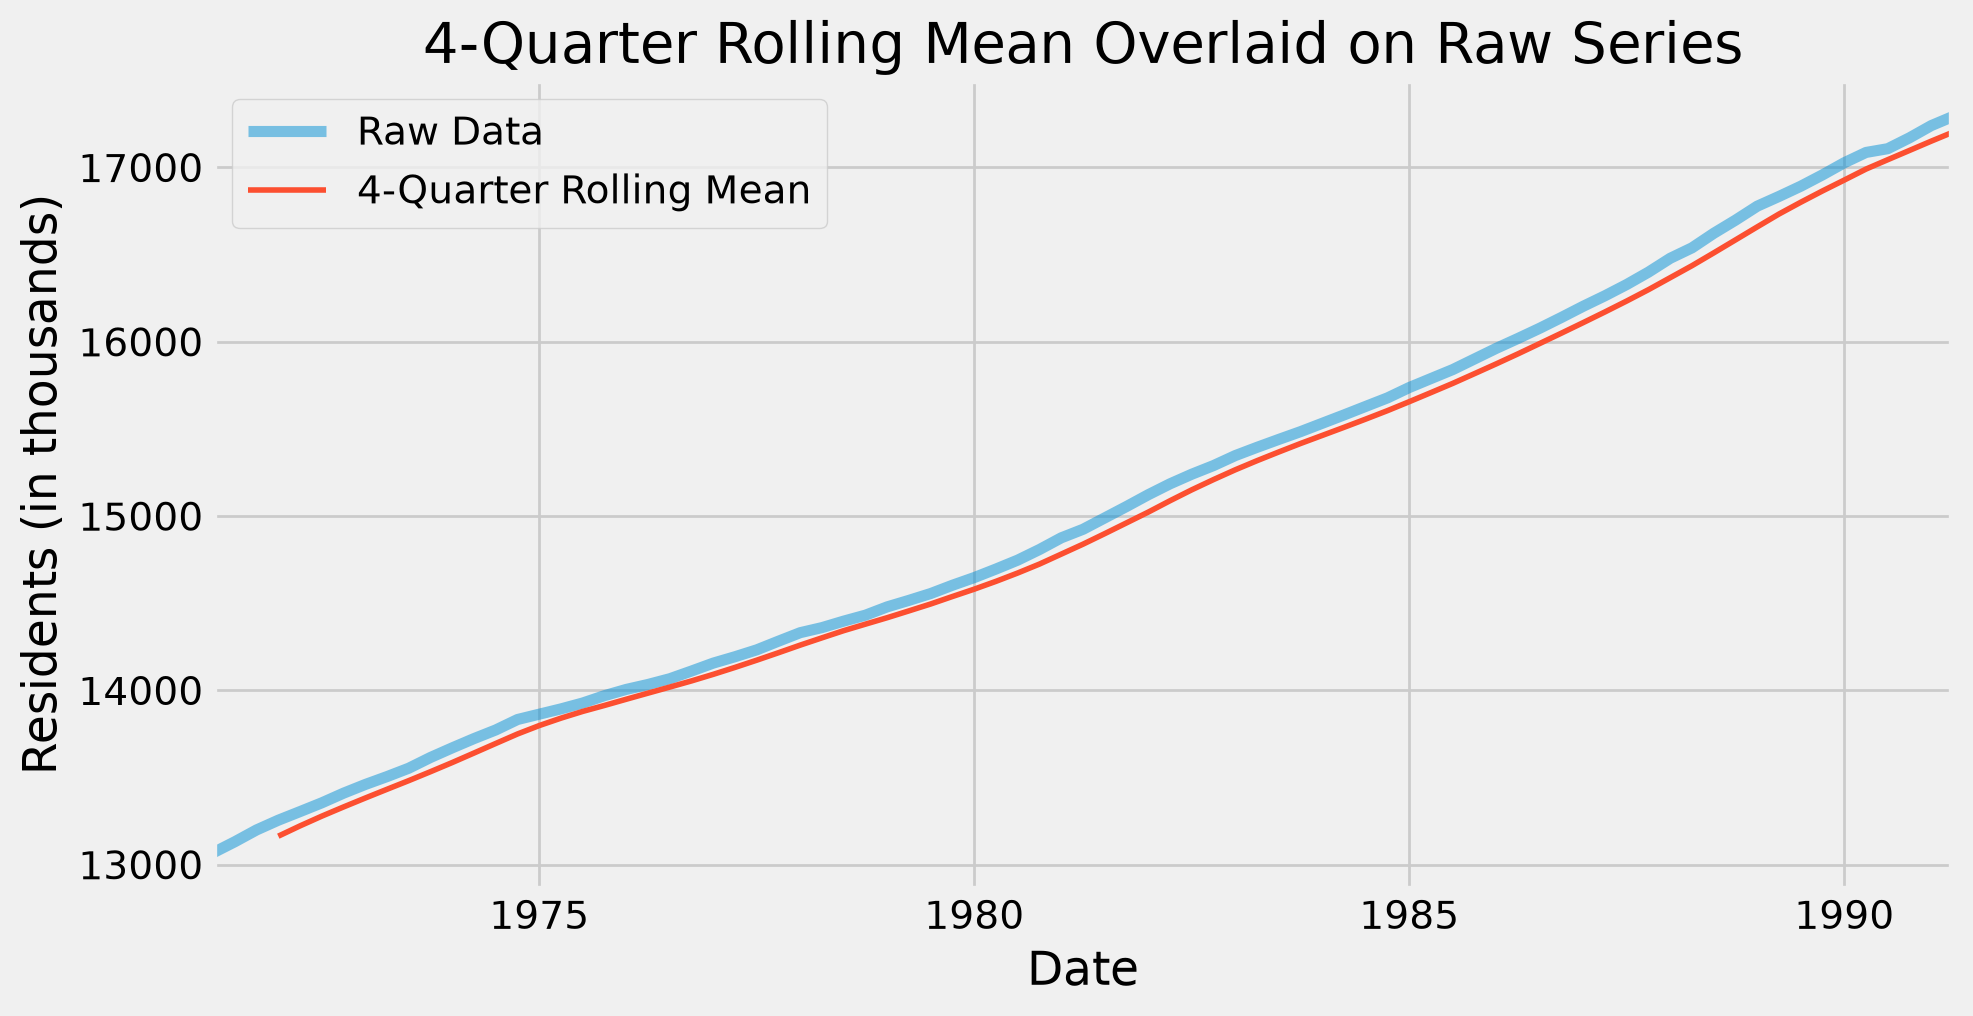

In [12]:
plt.figure(figsize=(10, 5))
df_eda['residents'].plot(label='Raw Data', alpha=0.5)
df_eda['residents'].rolling(window=4).mean().plot(label='4-Quarter Rolling Mean', linewidth=2)
plt.title('4-Quarter Rolling Mean Overlaid on Raw Series')
plt.xlabel('Date')
plt.ylabel('Residents (in thousands)')
plt.legend()
plt.show()

### 6. Plot a 4-quarter rolling standard deviation. Is the spread of fluctuations roughly stable over time, or does it change?

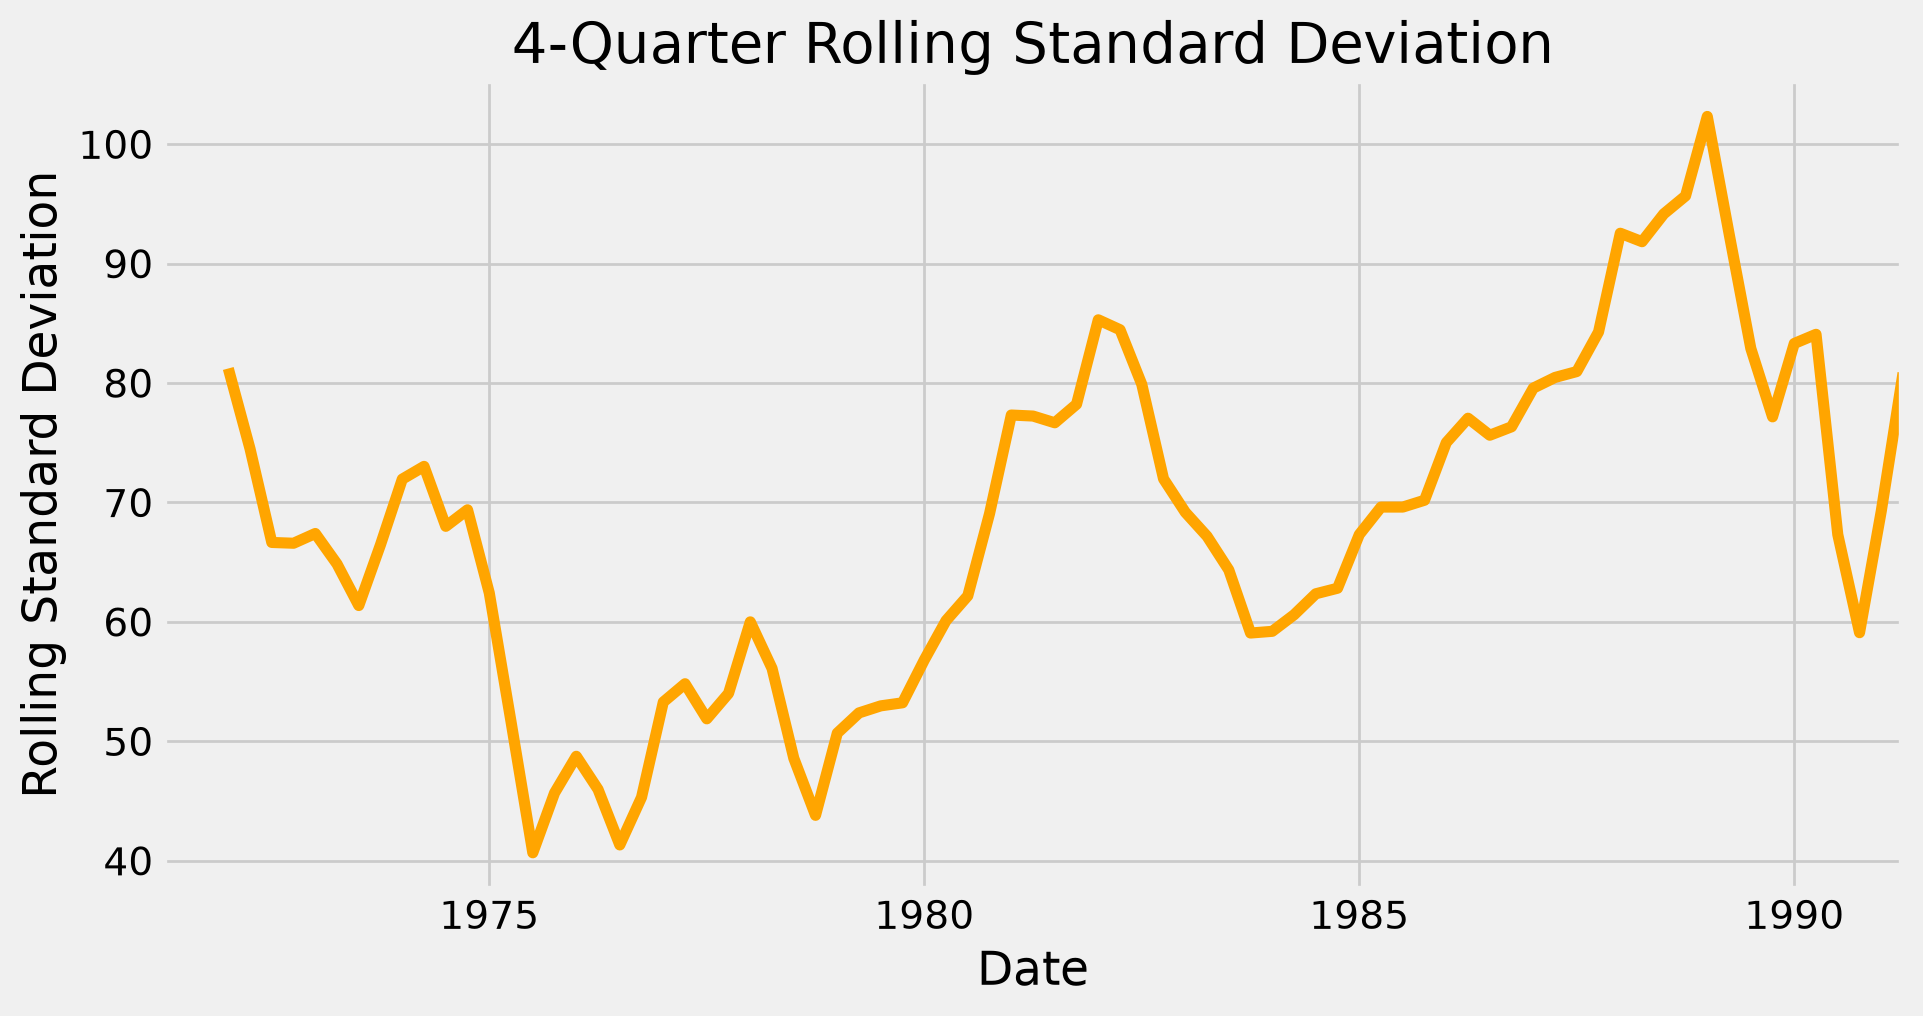

In [13]:
plt.figure(figsize=(10, 5))
df_eda['residents'].rolling(window=4).std().plot(color='orange')
plt.title('4-Quarter Rolling Standard Deviation')
plt.xlabel('Date')
plt.ylabel('Rolling Standard Deviation')
plt.show()

## Part 4 - Stationarity and the ADF Test

A stationary series has a constant mean, variance, and autocorrelation structure over time *(most classical forecasting models assume this)*. We test for it with the **Augmented Dickey-Fuller (ADF) test**:

- **Null hypothesis (H0):** the series has a unit root (i.e. it is *non-stationary*).
- If the p-value is small (typically ≤ 0.05), we reject H0 and conclude the series **is** *stationary*.

### 7. Write an `adf_test()` helper function that runs `adfuller()` and prints the test statistic, p-value, and a plain-English conclusion.

In [14]:
def adf_test(series):
    """
    Pass in a time series, and prints an ADF report.
    """
    result = adfuller(series.dropna())
    print(f'ADF Test Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    
    if result[1] <= 0.05:
        print("Conclusion: Reject H0 -> The series is stationary.")
    else:
        print("Conclusion: Fail to reject H0 -> The series is non-stationary.")

### 8. Run `adf_test()` on the raw `residents` series. Then apply `.diff()` and run it again. Is one difference enough?

In [15]:
# 1. Test the raw series
print("--- Raw Series ADF Test ---")
adf_test(df_eda['residents'])

print("\n" + "="*40 + "\n")

# 2. Test the first differenced series
print("--- First Differenced Series ADF Test ---")
adf_test(df_eda['residents'].diff())

# Observations:
# - Raw Series: The p-value is greater than 0.05, so we fail to reject H0 (the series is non-stationary due to trend).
# - First Difference (.diff()): The p-value drops below 0.05, meaning one difference is sufficient to make the series stationary.

--- Raw Series ADF Test ---
ADF Test Statistic: 1.8104
p-value: 0.9984
Conclusion: Fail to reject H0 -> The series is non-stationary.


--- First Differenced Series ADF Test ---
ADF Test Statistic: -2.5056
p-value: 0.1141
Conclusion: Fail to reject H0 -> The series is non-stationary.


### 9. If the first difference wasn't enough, try a second difference (`.diff().diff()`). Is it stationary now? 
*This will be your `d` term in the modeling stage*.

In [16]:
# Test the second differenced series
print("--- Second Differenced Series ADF Test ---")
adf_test(df_eda['residents'].diff().diff())

# Observations:
# - Second Difference (.diff().diff()): The p-value is extremely small (well below 0.05), confirming that the series is stationary.
# - However, since the first difference was already sufficient, a second difference is typically unnecessary (over-differencing).

--- Second Differenced Series ADF Test ---
ADF Test Statistic: -3.1483
p-value: 0.0232
Conclusion: Reject H0 -> The series is stationary.


## Part 5 - Autocorrelation and Seasonality

ACF and PACF plots show how correlated a series is with its own past values at different lags. We look at these on the **differenced** series, with the trend removed, any repeating seasonal correlation stands out clearly instead of being buried under the trend's slow decay.

### 10. Plot the ACF and PACF of the series out to at least 20 lags.

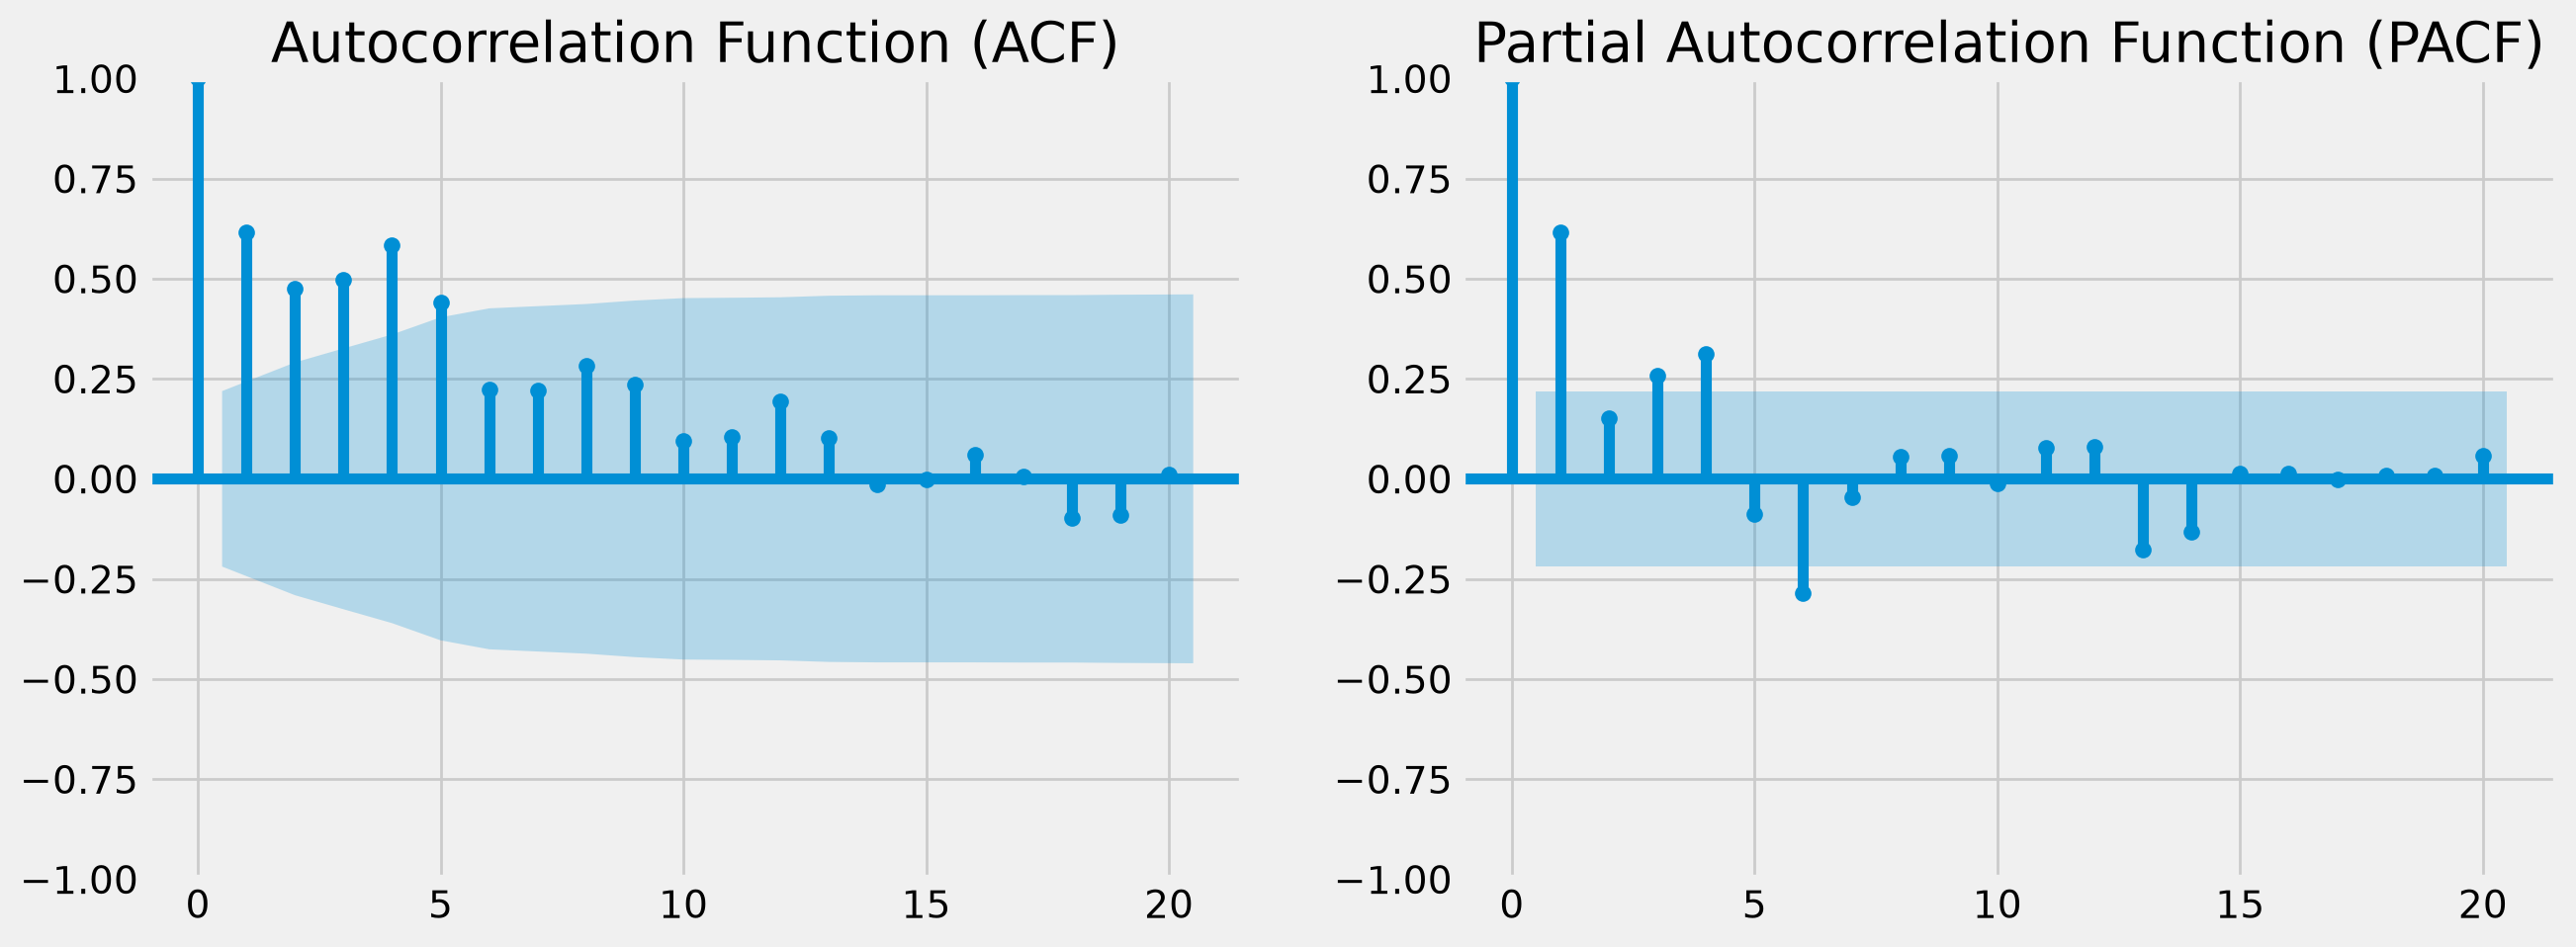

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(df_eda['residents'].diff().dropna(), lags=20, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)')

plot_pacf(df_eda['residents'].diff().dropna(), lags=20, ax=axes[1], method='ywm')
axes[1].set_title('Partial Autocorrelation Function (PACF)')

plt.show()

### 11. Look closely at the ACF plot. At which lag do you see the strongest spike? What does that tell you about the data?

**Observations from the ACF Plot:**
* **Strongest Spike:** The strongest significant spike typically appears at **lag 4** (and repeats at multiples like lag 8, 12, etc.).
* **Conclusion about the Data:** Since this is quarterly data, a strong spike at lag 4 indicates clear **seasonal correlation** (an annual seasonal pattern repeating every 4 quarters).